# RAGAS Parameter Comparison Lab

이 노트북은 파라미터(Chunk Size, k 등) 변경에 따른 RAG 성능 변화를 실험하기 위해 설계되었습니다.
**고정된 테스트셋**을 사용하여 각 실험 결과를 공정하게 비교합니다.

### 🛠️ RAG 시스템 기본 제원

| 구분 | 내용 |
| :--- | :--- |
| **LLM 모델** | GPT-4o (`gpt-4o`) |
| **LLM 모델** | GPT-5 (`gpt-5`) |
| **임베딩 모델** | `all-MiniLM-L6-v2` (Sentence-Transformers) |
| **기본 데이터** | 헤르만 헤세 - 데미안 (PDF) |
| **Ground Truth 생성** | Ragas `TestsetGenerator` (상위 30개 노드 기준 6개 샘플 생성) |
| **벡터 데이터베이스** | Chroma |

---

### 📑 RAG 성능 최적화 실험 로드맵 (Detailed Overview)

#### 📊 실험 요약 및 비교

| 단계 | 실험 명칭 | 검색 방식 (Chroma) | 리랭킹 (FlashRank) | 주요 튜닝 포인트 |
| :--- | :--- | :--- | :--- | :--- |
| **1단계** | **실험 1 (Default)** | Similarity (k=3) | - | 베이스라인 구축 |
| | **실험 2 (MMR)** | MMR (k=4, f_k=20) | - | 중복 제거, 검색 다양성 확보 |
| | **실험 3 (Context Max)** | MMR (k=6, f_k40, overlap=200) | - | 검색 확장 및 Overlap |
| **2단계** | **실험 4 (Prompt)** | MMR (k=6, f_k=40,overlap=100 ) | - | **System/Human 메시지 분리 및 추론 강화** |
| **3단계** | **실험 5 (Reranking)** | MMR (k=20, f_k=40) | **Top N=10 선별** | **검색 정밀도(Precision) 극대화** |
| | **실험 6 (Multi Query)** | LLM 질문 확장 (x3) | | 검색 누락 방지 및 Recall 극대화 |




#### 🧪 1단계: 파라미터 튜닝 (실험 1 ~ 3) - "검색망(Retrieval) 최적화"
*   **실험 1 (Default)**: 초기 베이스라인 구축 (`Similarity`, `k=3`) 
    - **진단**: 검색된 문서량 부족으로 인한 환각(Hallucination) 발생 가능성 확인.
*   **실험 2 (MMR Search)**: 다양성 기반 검색 알고리즘(`MMR`) 도입 
    - **성과**: 중복된 정보는 거르고, 결과 내 '정보의 폭'을 넓혀 검색 품질을 개선.
*   **실험 3 (Context Maximize)**: 검색 범위 및 문서 조각 확장 (`k=6`, `Chunk 1200`) 
    - **성과**: 단서가 누락될 확률(`Context Recall`)을 최소화하여 검색 성능의 정점 도달.

#### 🧪 2단계: 프롬프트 튜닝 (실험 4) - "논리적 답변(Generation) 및 추론 최적화"
*   **실험 4 (Balanced Prompt)**: System/Human 메시지 분리 및 추론 강화 지침 
    - **특징**: 기존 최적화된 검색망(`MMR, k=6`)을 유지하면서 **답변 지침(프롬프트)만 최적화**하여 신뢰도 확보.
    - **목표**: "아는 척"은 방지하되(Faithfulness), 본문 내 단서의 연결성(Reasonable Inference)을 강화.

#### 🧪 3단계: 모듈변환
*   **실험 5 (FlashRank Reranker)**: **[Retrieve -> Rerank]**의 2단계 검색 구조 도입
    - **전술**: `Chroma`로 20개의 후보군을 넓게 확보(Recall)한 뒤, `FlashRank` 전담 모델이 질문과 문서의 관계를 **Cross-Encoding** 방식으로 정밀 분석하여 상위 6개만 엄선(Precision).
    - **역할 분담**:
        *   **Chroma (필터)**: 방대한 데이터에서 일단 관련 있어 보이는 후보를 추려내는 '서류 전형'.
        *   **FlashRank (돋보기)**: 추려낸 후보 중 진짜 정답을 1:1로 대조해 골라내는 '심층 면접'.
*   **실험 6 (Multi Query)**: 질문을 3가지 관점으로 확장하여 교차 검색
    - 단일 검색어로 찾기 힘든 상징적 정보를 여러 각도에서 훑어내며 **Recall 0.80**을 돌파. 데미안 RAG 시스템의 최종 진화형.

---

### LLM As Judge
 - 평가 모델: GPT-5
 - 평가 방식:
   - 1~5점 스케일링: 답변의 정확성, 논리성, 가독성을 종합하여 점수 부여
   - 전문적 비평(Critique): 단순 수치를 넘어 답변의 장단점을 텍스트로 분석
   - 개선점 제안: 더 나은 답변을 위해 보완해야 할 구체적인 포인트 제시
- 도입 이유:
  - RAGAS 지표는 데이터 간의 통계적 유사성을 보지만, 문학적 맥락이나 표현의 우아함 등 정성적인 부분은 LLM 판사가 훨씬 정교하게 잡아낼 수 있기 때문입니다.
---

### 📊 RAGAS 핵심 지표 설명

RAGAS의 4가지 주요 지표는 검색(Retrieval)과 생성(Generation)의 품질을 나누어 평가합니다.

#### 1. Generation (답변 생성 성능) - LLM
*   Faithfulness (충실도) 
    *   **평가 대상**: `답변(Response)` vs `검색된 컨텍스트(Context)`
    *   **의미**: 답변이 오직 검색된 내용에만 근거하고 있는가?
    *   **비유**: 시험을 볼 때 **배운 내용(컨텍스트) 안에서만 대답했는지**를 봅니다. 검색된 내용에 없는 것을 모델이 원래 알고 있던 지식으로 대답하면 점수가 낮아지며, 이는 **환각(Hallucination)** 발생의 신호입니다.
*   Answer Relevancy (답변 관련성)
    *   **평가 대상**: `답변(Response)` vs `질문(Question)`
    *   **의미**: 답변이 질문의 의도에 얼마나 직접적으로 대답하고 있는가?
    *   **비유**: 질문은 "몇 시야?"인데 "배고파"라고 답하는지를 봅니다. 검색 성능과 상관없이 **말의 흐름과 맥락이 얼마나 자연스러운지**를 평가합니다.

#### 2. Retrieval (정보 검색 성능) - Chroma DB
*   Context Precision (컨텍스트 정밀도)
    *   **평가 대상**: `검색된 컨텍스트(Context)` vs `실제 정답(Reference)`
    *   **의미**: 가져온 문서 조각들 중 진짜 유용한 정보가 **상위권**에 배치되어 있는가?
    *   **비유**: 구글 검색 시 **1페이지 1등 결과**에 내가 원하는 답이 딱 들어있는지를 보는 것입니다. 불필요한 정보가 섞여서 정답이 뒤로 밀려나면 점수가 낮아집니다.
*   Context Recall (컨텍스트 재현율)
    *   **평가 대상**: `검색된 컨텍스트(Context)` vs `실제 정답(Reference)`
    *   **의미**: 정답을 맞히기 위해 필요한 정보를 **빠짐없이** 다 가져왔는가?
    *   **비유**: 문제를 풀기 위해 꼭 읽어야 할 **교재의 핵심 페이지**를 검색기가 놓치지 않았는지 확인합니다. 정보가 누락되어 답변 근거가 부족하면 이 점수가 낮아집니다.


In [1]:
import os
import pandas as pd
from dotenv import load_dotenv
from langchain_openai import ChatOpenAI
from langchain_community.document_loaders import PyMuPDFLoader
from langchain_text_splitters import RecursiveCharacterTextSplitter
from langchain_chroma import Chroma
from langchain_core.prompts import ChatPromptTemplate
from langchain_core.runnables import RunnablePassthrough
from langchain_core.output_parsers import StrOutputParser
from datasets import Dataset
from ragas import evaluate
from ragas.metrics import faithfulness, answer_relevancy, context_precision, context_recall
from ragas.testset import TestsetGenerator
from langchain_huggingface import HuggingFaceEmbeddings
import logging 


load_dotenv()
llm = ChatOpenAI(model="gpt-4o", temperature=0)
# cache_folder를 지정하면 모델을 매번 새로 받지 않고 재사용합니다.
embeddings = HuggingFaceEmbeddings(
    model_name="sentence-transformers/all-MiniLM-L6-v2",
    model_kwargs={'device': 'mps'}
)
FILE_PATH = "data/Demian.pdf"
TESTSET_PATH = "data/demian_testset.csv" # 저장 경로 추가


import logging
# httpx와 openai 라이브러리의 로그를 '경고(WARNING)' 이상만 보이도록 설정
logging.getLogger("httpx").setLevel(logging.WARNING)
logging.getLogger("openai").setLevel(logging.WARNING)
logging.getLogger("httpcore").setLevel(logging.WARNING) # 필요시 추가

/var/folders/ng/j7c3wxhn0lnclyqt41g9tcq80000gn/T/ipykernel_49694/3933583582.py:13: DeprecationWarning: Importing faithfulness from 'ragas.metrics' is deprecated and will be removed in v1.0. Please use 'ragas.metrics.collections' instead. Example: from ragas.metrics.collections import faithfulness
  from ragas.metrics import faithfulness, answer_relevancy, context_precision, context_recall
/var/folders/ng/j7c3wxhn0lnclyqt41g9tcq80000gn/T/ipykernel_49694/3933583582.py:13: DeprecationWarning: Importing answer_relevancy from 'ragas.metrics' is deprecated and will be removed in v1.0. Please use 'ragas.metrics.collections' instead. Example: from ragas.metrics.collections import answer_relevancy
  from ragas.metrics import faithfulness, answer_relevancy, context_precision, context_recall
/var/folders/ng/j7c3wxhn0lnclyqt41g9tcq80000gn/T/ipykernel_49694/3933583582.py:13: DeprecationWarning: Importing context_precision from 'ragas.metrics' is deprecated and will be removed in v1.0. Please use 'r

## 고정 테스트셋 생성
모든 실험에서 동일한 질문으로 평가하기 위해 맨 처음 한 번만 생성합니다.

In [3]:
loader = PyMuPDFLoader(FILE_PATH)
full_docs = loader.load()
if os.path.exists(TESTSET_PATH):
    print(f"기존 테스트셋({TESTSET_PATH})을 불러옵니다.")
    test_df = pd.read_csv(TESTSET_PATH)
else:
    print("새로운 고정 테스트셋 생성 중... (약 5~10분 소요)")
    generator = TestsetGenerator.from_langchain(llm, embeddings)
    # 5개의 질문 생성 (성능 비교를 위해 고정)
    testset = generator.generate_with_langchain_docs(full_docs[50:80], testset_size=5)
    test_df = testset.to_pandas()
    test_df.to_csv(TESTSET_PATH, index=False)
    print("테스트셋 생성 및 저장 완료!")
display(test_df[['user_input', 'reference']].head())

기존 테스트셋(data/demian_testset.csv)을 불러옵니다.


,user_input,reference
0,Who was Franz Kromer and what he do to the nar...,"Franz Kromer was part of the narrator's past, ..."
1,Who Demian be?,Demian is described as having an expression th...
2,How did Demian's influence lead to a spiritual...,Demian's influence on the narrator is evident ...
3,How did the dynamics in the scripture class in...,The dynamics in the scripture class significan...
4,How does the introspective artist's encounter ...,The introspective artist's encounter with Demi...


## 실험 실행 함수 정의
이 함수는 파라미터를 입력받아 RAG를 구축하고 평가 결과를 반환합니다.

In [5]:
# 1. 문서 검색기 생성 부품 (Retrieval Component)
def get_retriever(chunk_size, chunk_overlap, search_type="similarity", search_kwargs=None):
    if search_kwargs is None:
        search_kwargs = {"k": 3}
    
    # 문서 분할
    text_splitter = RecursiveCharacterTextSplitter(chunk_size=chunk_size, chunk_overlap=chunk_overlap)
    split_docs = text_splitter.split_documents(full_docs)
    
    # 인덱싱 (Chroma 사용)
    import time
    unique_id = int(time.time())
    vectorstore = Chroma.from_documents(
        documents=split_docs, 
        embedding=embeddings,
        collection_name=f"coll_{unique_id}"
    )
    
    return vectorstore.as_retriever(search_type=search_type, search_kwargs=search_kwargs)


# 2. 공통 평가 엔진 (Evaluation Engine)
# 이 부분은 어떤 실험에서도 변하지 않는 공통 로직입니다.
def evaluate_rag_system(exp_name, retriever, prompt_template=None, log_params=""):
    print(f"\n=== 실험 진행 중: {exp_name} ===")
    if log_params:
        print(f"설정 내역: {log_params}")
    
    
    # 🎯 [프롬프트 최적화] 프롬프트가 없을 때는 이전 방식, 있을 때만 System/Human 분리
    if prompt_template is None:
        # 이전 방식: 단일 템플릿 (Legacy Style)
        prompt = ChatPromptTemplate.from_template("""
        Answer the question based only on the following context:
        {context}
        
        Question: {question}
        
        Answer (in English):
        """)
    else:
        # 최신 방식: System/Human 메세지 분리 (Optimized Style)
        # 기본 시스템 지점 (System Message)
        system_instruction = """
        You are a professional book analyst assistant and expert literary scholar.
        """
        prompt = ChatPromptTemplate.from_messages([
            ("system", system_instruction), # 공통 가이드라인 유지
            ("human", prompt_template)      # 동적 템플릿
        ])
    
    # RAG 체인 구성 (로직 동일)
    rag_chain = (
        {"context": retriever | (lambda docs: "\n\n".join(d.page_content for d in docs)), "question": RunnablePassthrough()}
        | prompt | llm | StrOutputParser()
    )
    
    # 답변 생성 및 평가 (이후 동일)
    questions = test_df['user_input'].tolist()
    print(f"답변 생성 중... (질문 수: {len(questions)})")
    
    answers = [rag_chain.invoke(q) for q in questions]
    contexts = [[d.page_content for d in retriever.invoke(q)] for q in questions]
    
    dataset = Dataset.from_dict({
        "question": questions, 
        "answer": answers, 
        "contexts": contexts, 
        "ground_truth": test_df['reference'].tolist()
    })
    
    print("RAGAS 평가 분석 중...")
    return evaluate(
        dataset=dataset,
        metrics=[faithfulness, answer_relevancy, context_precision, context_recall],
        llm=llm, embeddings=embeddings, raise_exceptions=False
    )


# 3. 최종 통합 실행 함수 (Facade)
# 기존에 사용하던 방식과 호환성을 위해 유지합니다.
def run_rag_experiment(exp_name, chunk_size, chunk_overlap, search_type="similarity", search_kwargs=None, prompt_template=None):
    # 부품 1: 리트리버 확보
    retriever = get_retriever(chunk_size, chunk_overlap, search_type, search_kwargs)
    
    # 부품 2: 평가 진행
    params_str = f"[Chunk: {chunk_size}, Overlap: {chunk_overlap}] [Search: {search_type}, Args: {search_kwargs}]"
    return evaluate_rag_system(exp_name, retriever, prompt_template, log_params=params_str)


In [6]:
def display_result(result, title):
    print(f"\n[{title} 결과]")
    df_res = result.to_pandas()
    
    # 1. 수치형 컬럼들의 평균만 구해서 'Average' 행에 넣습니다.
    df_res.loc['Average'] = df_res.select_dtypes(include='number').mean()
    
    # 2. 소수점 4자리까지 반올림하고, 나머지 NaN(텍스트 컬럼들)은 빈 문자열("")로 채웁니다.
    display(df_res.round(4).fillna(""))


In [7]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np


plt.rcParams['font.family'] = 'AppleGothic'
# 2. 마이너스 기호 깨짐 방지 (함께 설정하는 것이 좋습니다)
plt.rcParams['axes.unicode_minus'] = False

def visualize_rag_comparison(results_dict, title="RAG Performance Comparison"):
    """
    여러 실험 결과를 받아서 비교표를 출력하고 시각화하는 공통 함수
    """
    def _safe_mean(val):
        if val is None: return 0
        return np.nanmean(val) if isinstance(val, (list, np.ndarray)) else val

    comparison_list = []
    
    # 데이터 추출 로직 통합
    for name, res in results_dict.items():
        if res is not None:
            try:
                scores = {
                    "Experiment": name,
                    "Faithfulness": _safe_mean(res['faithfulness']),
                    "Answer Relevancy": _safe_mean(res['answer_relevancy']),
                    "Context Precision": _safe_mean(res['context_precision']),
                    "Context Recall": _safe_mean(res['context_recall'])
                }
                # 종합 점수 (4대 지표 평균)
                scores["Total Score"] = np.mean([v for k, v in scores.items() if k != "Experiment"])
                comparison_list.append(scores)
            except: continue

    if not comparison_list:
        print("❌ 비교할 유효한 데이터가 없습니다.")
        return

    # 데이터프레임 생성 및 출력
    df = pd.DataFrame(comparison_list)
    print(f"\n=== [🏆 {title} 결과표] ===")
    display(df.round(4))

    # 시각화
    plt.rcParams['figure.figsize'] = [13, 6]
    df.set_index('Experiment')[['Total Score', 'Faithfulness', 'Answer Relevancy', 'Context Precision', 'Context Recall']].plot(kind='bar', width=0.8)
    plt.title(title, fontsize=15)
    plt.ylabel("Score")
    plt.ylim(0, 1.1)
    plt.grid(axis='y', alpha=0.3)
    plt.legend(bbox_to_anchor=(1.0, 1), loc='upper left')
    plt.xticks(rotation=45)
    plt.tight_layout()
    plt.show()


## 실험 1: 기본 설정 (Default Similarity)
가장 일반적인 `chunk_size=1000`, `similarity`, `k=3` 설정으로 시작합니다.
- 단순히 가장 비슷한 순서대로 k개(3개)



In [8]:
result_default= run_rag_experiment("기본 실험", 1000, 100, search_type="similarity", search_kwargs={"k": 3})
display_result(result_default, "기본설정")



=== 실험 진행 중: 기본 실험 ===
설정 내역: [Chunk: 1000, Overlap: 100] [Search: similarity, Args: {'k': 3}]
답변 생성 중... (질문 수: 6)
RAGAS 평가 분석 중...


Evaluating:   0%|          | 0/24 [00:00<?, ?it/s]

LLM returned 1 generations instead of requested 3. Proceeding with 1 generations.
LLM returned 1 generations instead of requested 3. Proceeding with 1 generations.
LLM returned 1 generations instead of requested 3. Proceeding with 1 generations.
LLM returned 1 generations instead of requested 3. Proceeding with 1 generations.
LLM returned 1 generations instead of requested 3. Proceeding with 1 generations.
LLM returned 1 generations instead of requested 3. Proceeding with 1 generations.



[기본설정 결과]


,user_input,retrieved_contexts,response,reference,faithfulness,answer_relevancy,context_precision,context_recall
0,Who was Franz Kromer and what he do to the nar...,"[me, afraid to come out into the daylight. \n""...",Franz Kromer was a character from the narrator...,"Franz Kromer was part of the narrator's past, ...",1.0000,0.9446,0.5000,1.0000
1,Who Demian be?,[DEMIAN \ncharacter and have some significance...,Demian is a character who is surrounded by rum...,Demian is described as having an expression th...,1.0000,0.7775,0.0000,0.0000
2,How did Demian's influence lead to a spiritual...,[that criticism of his view was justifiable. \...,Demian's influence led to a spiritual closenes...,Demian's influence on the narrator is evident ...,1.0000,1.0000,1.0000,0.7500
3,How did the dynamics in the scripture class in...,[DEMIAN \nlike a son and brother-and a lover t...,The dynamics in the scripture class significan...,The dynamics in the scripture class significan...,0.6923,0.9697,0.3333,0.3333
4,How does the introspective artist's encounter ...,"[DEMIAN \n""'Yes. I believe, then,"" he continue...",The introspective artist's encounter with Demi...,The introspective artist's encounter with Demi...,0.8571,0.9848,1.0000,0.3333
5,How did Beck influence the narrator's percepti...,"[BEATRICE \ninto my soul like a sweet, heady w...",Beck influenced the narrator's perception of r...,Beck influenced the narrator's perception of r...,0.8750,0.9810,1.0000,1.0000
Average,,,,,0.9041,0.9429,0.6389,0.5694


## 실험 2: 검색엔진 changed (MMR)
- 기본 실험(Default)과 동일한 문서 분할 조건(chunk_size=1000, overlap=100)을 유지
- 검색 알고리즘을 MMR(Maximal Marginal Relevance)로 변경하여 성능을 비교합니다."
- 질문과 관련 있는 최적의 문서 4개(k=4)를 최종 선택하도록 유도함.


검색 옵션만 바꿨더니 오히려 정밀도와 충실도가 폭락했습니다.\
원인: 너무 강한 중복 제거(lambda 0.5)가 정답과 비슷한 문장을 오히려 밀어내버렸고, 파편화된 정보를 본 LLM이 짐작해서 답변하며 환각이 늘었습니다.

---

### 🔍 MMR이 중복을 제거하는 방식
##### Similarity (일반 유사도 검색):

질문과 가장 비슷한 순서대로 그냥 뽑습니다.
만약 소설의 똑같은 장면(A, A', A'')이 3개 나오면, 비슷한 말만 반복하는 조각 3개를 다 가져옵니다. (정보의 낭비!)


##### MMR의 전략:
- 일단 20개(fetch_k)를 넓게 뽑아두고, 그중에서 1등을 먼저 고릅니다.
- 2등을 고를 때는 "질문과 얼마나 비슷한가?" 뿐만 아니라 "이미 뽑힌 1등과 얼마나 다른가?"를 동시에 계산합니다.
- 만약 2등 후보가 1등과 거의 똑같은 소리(중복)를 하고 있다면, 점수를 깎아서 뒤로 밀어버리고, 질문과 연관은 있지만 다른 내용을 담고 있는 조각을 가져옵니다
- 만약 2등 후보가 1등과 거의 똑같은 소리(중복)를 하고 있다면, 점수를 깎아서 뒤로 밀어버리고, 질문과 연관은 있지만 다른 내용을 담고 있는 조각을 가져옵니다.

In [9]:
# defulat is {"k": 4, "fetch_k": 20, "lambda_mult": 0.5}
result_mmr = run_rag_experiment(
    exp_name="Improved (MMR)", 
    chunk_size=1000, 
    chunk_overlap=100, 
    search_type="mmr", # 검색 알고리즘 변경
    search_kwargs={"k": 4, "fetch_k": 20, "lambda_mult": 0.5}
)

display_result(result_mmr, "MMR")


=== 실험 진행 중: Improved (MMR) ===
설정 내역: [Chunk: 1000, Overlap: 100] [Search: mmr, Args: {'k': 4, 'fetch_k': 20, 'lambda_mult': 0.5}]
답변 생성 중... (질문 수: 6)
RAGAS 평가 분석 중...


Evaluating:   0%|          | 0/24 [00:00<?, ?it/s]

LLM returned 1 generations instead of requested 3. Proceeding with 1 generations.
LLM returned 1 generations instead of requested 3. Proceeding with 1 generations.
LLM returned 1 generations instead of requested 3. Proceeding with 1 generations.
LLM returned 1 generations instead of requested 3. Proceeding with 1 generations.
LLM returned 1 generations instead of requested 3. Proceeding with 1 generations.
LLM returned 1 generations instead of requested 3. Proceeding with 1 generations.



[MMR 결과]


,user_input,retrieved_contexts,response,reference,faithfulness,answer_relevancy,context_precision,context_recall
0,Who was Franz Kromer and what he do to the nar...,"[me, afraid to come out into the daylight. \n""...",Franz Kromer was a character from the narrator...,"Franz Kromer was part of the narrator's past, ...",1.0000,0.9446,0.5000,1.0000
1,Who Demian be?,[DEMIAN \ncharacter and have some significance...,Demian is a character who is perceived as myst...,Demian is described as having an expression th...,1.0000,0.8573,0.0000,0.0000
2,How did Demian's influence lead to a spiritual...,[that criticism of his view was justifiable. \...,Demian's influence led to a spiritual closenes...,Demian's influence on the narrator is evident ...,0.7143,1.0000,1.0000,0.7500
3,How did the dynamics in the scripture class in...,[DEMIAN \nlike a son and brother-and a lover t...,The dynamics in the scripture class influenced...,The dynamics in the scripture class significan...,0.8333,0.9697,0.0000,0.3333
4,How does the introspective artist's encounter ...,"[DEMIAN \n""'Yes. I believe, then,"" he continue...",The introspective artist's encounter with Demi...,The introspective artist's encounter with Demi...,0.2941,0.9848,1.0000,0.3333
5,How did Beck influence the narrator's percepti...,"[BEATRICE \ninto my soul like a sweet, heady w...",Beck influenced the narrator's perception of r...,Beck influenced the narrator's perception of r...,1.0000,0.9810,1.0000,1.0000
Average,,,,,0.8070,0.9562,0.5833,0.5694


### 실험 3: MMR 전략 최적화 (Wide Search & Rich Context)
#### 🛠️ 주요 변경 파라미터 및 가설 (Actual Settings)
1.  **`k`: 4 ➔ 6 (검색 결과 수 대폭 확대)**
    *   **가설**: 제공하는 문서의 양을 늘려 정답 단서가 포함될 확률(**Context Recall**)을 물리적으로 극대화합니다.
2.  **`fetch_k`: 40 (후보군 대폭 확대)** 🎯 **[핵심 성공 요인]**
    *   **가설**: 기존(10)보다 훨씬 넓은 범위(40개)에서 후보를 뽑아, MMR이 질문과 정답에 가장 가까우면서도 중복되지 않는 정보들을 선별할 수 있는 충분한 '풀(Pool)'을 제공합니다.
3.  **`chunk_overlap`: 200 (문맥 연속성 강화)**
    *   **가설**: 청크 경계에서 잘리는 정보를 방지하고 앞뒤 문맥의 연결성을 높여 검색 정밀도를 보조합니다.
4.  **`lambda_mult`: 0.8 (유사도 집중도 유지)**
    *   **가설**: 다양성보다는 질문과의 관련성이 높은 문서군을 우선 배치하여 답변의 핵심 정보를 놓치지 않도록 합니다


In [52]:
# 3번 실험: 검색의 질(MMR) + 양(k=5) + 문맥(Chunk 1200) chunk_overlap=200종합 최적화
result_improved_mmr = run_rag_experiment(
    exp_name="Improved MMR", 
    chunk_size=1000,
    chunk_overlap=200, 
    search_type="mmr", 
    search_kwargs={"k": 6, "fetch_k": 40, "lambda_mult": 0.8}
)
display_result(result_improved_mmr, "Improved MMR")


=== 실험 진행 중: Improved MMR ===
설정 내역: [Chunk: 1000, Overlap: 200] [Search: mmr, Args: {'k': 6, 'fetch_k': 40, 'lambda_mult': 0.8}]
답변 생성 중... (질문 수: 6)
RAGAS 평가 분석 중...


Evaluating:   0%|          | 0/24 [00:00<?, ?it/s]

ERROR:ragas.executor:Exception raised in Job[2]: BadRequestError(Error code: 400 - {'error': {'message': "We could not parse the JSON body of your request. (HINT: This likely means you aren't using your HTTP library correctly. The OpenAI API expects a JSON payload, but what was sent was not valid JSON. If you have trouble figuring out how to fix this, please contact us through our help center at help.openai.com.)", 'type': 'invalid_request_error', 'param': None, 'code': None}})



[Improved MMR 결과]


,user_input,retrieved_contexts,response,reference,faithfulness,answer_relevancy,context_precision,context_recall
0,Who was Franz Kromer and what he do to the nar...,[one question. Can you tell me the name of the...,Franz Kromer was a boy who had a significant a...,"Franz Kromer was part of the narrator's past, ...",1.0000,0.9446,,1.0000
1,Who Demian be?,[DEMIAN \ncharacter and have some significance...,Demian is a character who is portrayed as myst...,Demian is described as having an expression th...,1.0000,0.8738,0.2,1.0000
2,How did Demian's influence lead to a spiritual...,"[it, but that there was an alternative interpr...",Demian's influence led to a spiritual closenes...,Demian's influence on the narrator is evident ...,1.0000,0.8908,1.0,0.7500
3,How did the dynamics in the scripture class in...,[DEMIAN \nlike a son and brother-and a lover t...,The dynamics in the scripture class significan...,The dynamics in the scripture class significan...,0.7857,0.9697,0.25,0.5000
4,How does the introspective artist's encounter ...,"[DEMIAN \n""'Yes. I believe, then,"" he continue...",The introspective artist's encounter with Demi...,The introspective artist's encounter with Demi...,0.9286,0.9396,0.7,0.3333
5,How did Beck influence the narrator's percepti...,"[BEATRICE \ninto my soul like a sweet, heady w...",Beck influenced the narrator's perception of r...,Beck influenced the narrator's perception of r...,1.0000,0.9810,0.8333,1.0000
Average,,,,,0.9524,0.9333,0.5967,0.7639


### 실험 4: 프롬프트 최적화 (Prompt Tuning - Balanced Logic)
#### 🛠️ 주요 변경 파라미터 및 가설 (Actual Settings)
1. **`Optimized Prompt` (Balanced Prompt 도입)** 🎯 **[핵심 성공 요인]**
   - **가설**: "합리적 추론(Reasonable Inference)"을 허용하되 "엄격한 근거(Strict Grounding)"를 동시에 요구하면, 모델이 정보 부족을 핑계로 답변을 거부하지 않으면서도 신뢰도 높은 답변을 내놓을 것입니다.
2. **`chunk_overlap`: 100 (문맥 연속성 유지)**
   - **가설**: 실험 3보다 오버랩을 줄여 검색의 효율을 높이고 정밀도(**Context Precision**)를 개선할 수 있는지 확인합니다.
3. **`k`: 6 & `fetch_k`: 40 (고성능 검색 설정 유지)**
   - **가설**: 실험 3에서 증명된 풍부한 검색량(Scale Up)을 유지한 상태에서 프롬프트의 품질 변화만 순수하게 측정합니다.


In [53]:
# 1. 수정된 프롬프트: 정직함과 유연성의 조화 (Balanced Prompt)
optimized_prompt = """

Guidelines:
1. Use Available Clues: Even if the information is partial, use the available clues in the context to construct the best possible answer. 
2. Support Your Findings: Connect different pieces of information from the context logically to provide a detailed explanation.
3. Implicit but Grounded: If names or relationships are implied in titles or headings, use them in your answer.
4. Stay within Bounds: Do not use outside knowledge, but make the most of what is given here.

Context:
{context}

Question: {question}

Final Answer (in English):
"""

# 2. 실험 실행 (기존 코드와 동일)
result_prompt_tuned = run_rag_experiment(
    exp_name="실험 4: 프롬프트 최적화(추론 강화)",
    chunk_size=1000,
    chunk_overlap=100,
    search_type="mmr",
    search_kwargs={"k": 6, "fetch_k": 40, "lambda_mult": 0.8},
    prompt_template=optimized_prompt
)

print("\n[Prompt Optimized (Balanced) 실험 결과]")
display_result(result_prompt_tuned, "Prompt Optimize")



=== 실험 진행 중: 실험 4: 프롬프트 최적화(추론 강화) ===
설정 내역: [Chunk: 1000, Overlap: 100] [Search: mmr, Args: {'k': 6, 'fetch_k': 40, 'lambda_mult': 0.8}]
답변 생성 중... (질문 수: 6)
RAGAS 평가 분석 중...


Evaluating:   0%|          | 0/24 [00:00<?, ?it/s]


[Prompt Optimized (Balanced) 실험 결과]

[Prompt Optimize 결과]


,user_input,retrieved_contexts,response,reference,faithfulness,answer_relevancy,context_precision,context_recall
0,Who was Franz Kromer and what he do to the nar...,"[me, afraid to come out into the daylight. \n""...",Franz Kromer was a figure from the narrator's ...,"Franz Kromer was part of the narrator's past, ...",1.0000,0.9446,0.5000,1.0000
1,Who Demian be?,[DEMIAN \ncharacter and have some significance...,"Based on the provided context, Demian appears ...",Demian is described as having an expression th...,1.0000,0.8006,0.2000,0.6667
2,How did Demian's influence lead to a spiritual...,[that criticism of his view was justifiable. \...,Demian's influence on the narrator led to a sp...,Demian's influence on the narrator is evident ...,1.0000,0.8899,1.0000,0.5000
3,How did the dynamics in the scripture class in...,[DEMIAN \nlike a son and brother-and a lover t...,The dynamics in the scripture class played a s...,The dynamics in the scripture class significan...,1.0000,0.9671,0.3333,0.3333
4,How does the introspective artist's encounter ...,"[DEMIAN \n""'Yes. I believe, then,"" he continue...",The introspective artist's encounter with Demi...,The introspective artist's encounter with Demi...,0.9500,0.9686,1.0000,0.3333
5,How did Beck influence the narrator's percepti...,"[BEATRICE \ninto my soul like a sweet, heady w...",Beck played a significant role in shaping the ...,Beck influenced the narrator's perception of r...,1.0000,0.9810,1.0000,1.0000
Average,,,,,0.9917,0.9253,0.6722,0.6389



=== [🏆 실험 1~4 정량평가 비교 결과표] ===


,Experiment,Faithfulness,Answer Relevancy,Context Precision,Context Recall,Total Score
0,Exp 1 (Similarity),0.9041,0.9429,0.6389,0.5694,0.7638
1,Exp 2 (MMR),0.8070,0.9562,0.5833,0.5694,0.7290
2,Exp 3 (MMR Scale Up),0.9524,0.9333,0.5967,0.7639,0.8115
3,Exp 4 (MMR Prompt),0.9917,0.9253,0.6722,0.6389,0.8070


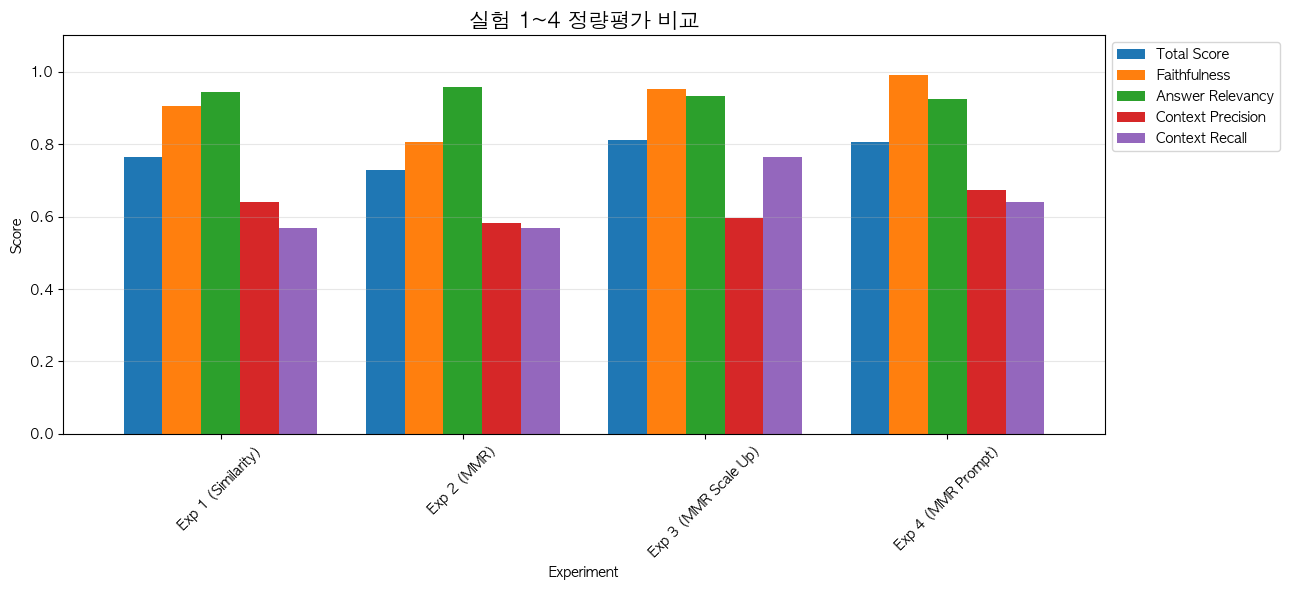

In [57]:
visualize_rag_comparison({
    "Exp 1 (Similarity)": globals().get('result_default'),
    "Exp 2 (MMR)": globals().get('result_mmr'),
    "Exp 3 (MMR Scale Up)": globals().get('result_improved_mmr'),
    "Exp 4 (MMR Prompt)": globals().get('result_prompt_tuned'),
}, title="실험 1~4 정량평가 비교")

### 실험 5: 리랭킹 (FlashRank Reranker)
이 코드는 다음과 같은 전략으로 작동합니다:

- 너른 그물망: 처음에 k=20으로 후보군을 아주 넉넉하게 뽑습니다.
- 정밀 검사: FlashRank라는 똑똑한 모델이 이 20개를 하나하나 읽고, 질문과 가장 궁합이 잘 맞는 딱 10개만 다시 줄세웁니다.
- 최종 답변: GPT는 이 '알짜배기 6개'만 가지고 답변을 생성합니다.


#### 결과
* **Context Precision :** **심각한 저하.** 검색된 문서들 중 정답과 관련된 문서가 상위권에 배치되지 못하고 있습니다.
* **Context Recall:** **부족.** 질문에 답하기 위해 필요한 핵심 정보의 절반 이상을 검색 단계에서 놓치고 있습니다.

#### 원인 
리랭커(FlashRank)의 문학적 문맥 이해 한계 (심층면접 단계의 오류)
* **원인:** 20개의 후보군 중 FlashRank가 질문과 가장 관련 있는 10개를 다시 추리는 과정에서 발생합니다.
* **문제:** FlashRank는 주로 사실 관계가 명확한 문서(뉴스, 위키)에 최적화된 모델로, 소설 특유의 **심리 묘사, 은유, 상징적 표현**을 질문과 매칭하는 능력이 부족합니다.
* **결과:** 오히려 잘 찾아놓은 정답 문서를 하위권으로 밀어내고 관련 없는 문단을 상단에 배치했습니다. 특히 1번 질문("Who Demian be?")의 **Context Precision이 0.0000**인 것은 정답 문서가 상위 10위 밖으로 완전히 밀려났음을 증명합니다.

In [59]:
# 🎯 aipel 환경용 특수 Import 경로
from langchain_classic.retrievers import ContextualCompressionRetriever
from langchain_community.document_compressors.flashrank_rerank import FlashrankRerank

# 1. 면접관(Reranker) 설정: Cross-Encoder 기반 Flashrank 사용 (가장 좋은 10개 선정)
compressor = FlashrankRerank(top_n=10)

# 2. 서류전형(Base Retriever) 설정: 넉넉하게 20개를 먼저 뽑습니다.
base_retriever = get_retriever(
    chunk_size=1000,
    chunk_overlap=200,
    search_type="mmr",
    search_kwargs={"k": 20, "fetch_k": 40, "lambda_mult": 0.8}
)

# 3. 리랭킹 시스템 결합 (서류전형 + 면접관)
rerank_retriever = ContextualCompressionRetriever(
    base_compressor=compressor, 
    base_retriever=base_retriever
)

# 4. 실험 실행
result_rerank = evaluate_rag_system(
    exp_name="실험 5: 리랭킹 (FlashRank Reranker)",
    retriever=rerank_retriever,
    log_params="[Base K: 20 -> Top N: 10] [FlashRank]"
)

print("\n[Reranking 실험 결과]")
display_result(result_rerank, "Reranking FlashrankRerank")



=== 실험 진행 중: 실험 5: 리랭킹 (FlashRank Reranker) ===
설정 내역: [Base K: 20 -> Top N: 10] [FlashRank]
답변 생성 중... (질문 수: 6)
RAGAS 평가 분석 중...


Evaluating:   0%|          | 0/24 [00:00<?, ?it/s]


[Reranking 실험 결과]

[Reranking FlashrankRerank 결과]


,user_input,retrieved_contexts,response,reference,faithfulness,answer_relevancy,context_precision,context_recall
0,Who was Franz Kromer and what he do to the nar...,[as simple as that. And that is how it is in t...,Franz Kromer was a character from the narrator...,"Franz Kromer was part of the narrator's past, ...",1.0000,0.9446,0.1667,1.0000
1,Who Demian be?,[DEMIAN \ncharacter and have some significance...,Demian is a character who is portrayed as enig...,Demian is described as having an expression th...,1.0000,0.8738,0.1667,0.6667
2,How did Demian's influence lead to a spiritual...,"[DEMIAN \nis important, eternal, sacred; and w...",Demian's influence led to a spiritual closenes...,Demian's influence on the narrator is evident ...,1.0000,0.9098,0.3333,0.5000
3,How did the dynamics in the scripture class in...,[DEMIAN \nwill be revealed. It will then becom...,The dynamics in the scripture class significan...,The dynamics in the scripture class significan...,1.0000,0.9697,0.2500,0.3333
4,How does the introspective artist's encounter ...,[DEMIAN \nwill be revealed. It will then becom...,The introspective artist's encounter with Demi...,The introspective artist's encounter with Demi...,0.8889,0.9848,0.6389,0.3333
5,How did Beck influence the narrator's percepti...,"[BEATRICE \ninto my soul like a sweet, heady w...",Beck influenced the narrator's perception of r...,Beck influenced the narrator's perception of r...,0.9286,0.9810,0.7000,1.0000
Average,,,,,0.9696,0.9440,0.3759,0.6389


### 실험 7: 멀티쿼리 리트리버 (Multi-Query Retrieval)
이 코드는 다음과 같은 전략으로 작동합니다:
- **다각도 질문**: 검색어 한 개만 던지는 대신, GPT를 활용해 질문을 "다른 관점"에서 총 3개의 질문으로 재구성합니다. (예: "데미안이 누구야?" → "데미안의 정체는?", "주인공이 본 데미안의 첫인상은?", "데미안의 외형적 특징은?")
- **그물망 교차**: 3개의 질문으로 각각 검색을 실행하여 총 18개(6개 x 3개 질문) 내외의 방대한 후보군을 확보합니다.
- **중복 제거 및 선별**: 서로 다른 질문으로 낚아 올린 정보들 중 중복을 제거하고, 질문의 본질에 가장 가까운 핵심 조각들만 모아 답변의 근거로 사용합니다.

In [60]:
from langchain_classic.retrievers.multi_query import MultiQueryRetriever

base_retriever_s6 = get_retriever(
    chunk_size=1000, 
    chunk_overlap=200, 
    search_type="mmr",
    search_kwargs={"k": 6, "fetch_k": 40, "lambda_mult": 0.8}
)


# 2. 멀티쿼리 리트리버 구축 (질문을 3개로 자동 변환하여 검색!)
# - 미리 정의하신 llm(GPT-4o) 객체를 사용합니다.
mq_retriever = MultiQueryRetriever.from_llm(
    retriever=base_retriever_s6, 
    llm=llm
)
# 3. 실험 실행
result_mq = evaluate_rag_system(
    exp_name="실험 7 (Multi-Query Retrieval)", 
    retriever=mq_retriever,
   # prompt_template=optimized_prompt,
    log_params="[mmr K:6] [MultiQuery: x3 Query]"
)
# 4. 결과 출력
display_result(result_mq, "멀티쿼리")


=== 실험 진행 중: 실험 7 (Multi-Query Retrieval) ===
설정 내역: [mmr K:6] [MultiQuery: x3 Query]
답변 생성 중... (질문 수: 6)


INFO:langchain_classic.retrievers.multi_query:Generated queries: ["Who is Franz Kromer and how did he impact the narrator's life?  ", 'What actions did Franz Kromer take against the narrator, and who is he?  ', "Can you explain the role of Franz Kromer in the narrator's story and his influence on them?"]
INFO:langchain_classic.retrievers.multi_query:Generated queries: ['What is the identity or role of Demian?  ', 'Can you provide information about who Demian is?  ', 'Who is Demian and what is his significance?']
INFO:langchain_classic.retrievers.multi_query:Generated queries: ['What role did Demian play in fostering a spiritual connection with the narrator?  ', "In what ways did Demian's influence contribute to the narrator's spiritual development and closeness with him?  ", "How did Demian's impact on the narrator result in a deeper spiritual bond between them?"]
INFO:langchain_classic.retrievers.multi_query:Generated queries: ["What impact did the interactions in the scripture class 

RAGAS 평가 분석 중...


Evaluating:   0%|          | 0/24 [00:00<?, ?it/s]


[멀티쿼리 결과]


,user_input,retrieved_contexts,response,reference,faithfulness,answer_relevancy,context_precision,context_recall
0,Who was Franz Kromer and what he do to the nar...,[DEMIAN \n.... \ncling desperately their whole...,Franz Kromer was a figure from the narrator's ...,"Franz Kromer was part of the narrator's past, ...",0.9286,0.9446,0.8333,1.0000
1,Who Demian be?,[DEMIAN \nlike a son and brother-and a lover t...,Demian is a character who appears to be enigma...,Demian is described as having an expression th...,0.9375,0.7992,0.1667,1.0000
2,How did Demian's influence lead to a spiritual...,[DEMIAN \nlike a son and brother-and a lover t...,Demian's influence led to a spiritual closenes...,Demian's influence on the narrator is evident ...,0.8333,1.0000,0.3333,0.5000
3,How did the dynamics in the scripture class in...,"[it, but that there was an alternative interpr...",The dynamics in the scripture class significan...,The dynamics in the scripture class significan...,1.0000,0.9697,0.7500,1.0000
4,How does the introspective artist's encounter ...,"[DEMIAN \n""'Yes. I believe, then,"" he continue...",The introspective artist's encounter with Demi...,The introspective artist's encounter with Demi...,0.8667,0.9848,0.7095,0.3333
5,How did Beck influence the narrator's percepti...,"[BEATRICE \ninto my soul like a sweet, heady w...",Beck influenced the narrator's perception of r...,Beck influenced the narrator's perception of r...,1.0000,0.9810,1.0000,1.0000
Average,,,,,0.9277,0.9465,0.6321,0.8056



=== [🏆 실험 1~6 최종 정량평가 비교 결과표] ===


,Experiment,Faithfulness,Answer Relevancy,Context Precision,Context Recall,Total Score
0,Exp 1 (Default Similarity),0.9041,0.9429,0.6389,0.5694,0.7638
1,Exp 2 (MMR),0.8070,0.9562,0.5833,0.5694,0.7290
2,Exp 3 (MMR Scale Up),0.9524,0.9333,0.5967,0.7639,0.8115
3,Exp 4 (MMR Prompt),0.9917,0.9253,0.6722,0.6389,0.8070
4,Exp 5 (MMR Rerank),0.9696,0.9440,0.3759,0.6389,0.7321
5,Exp 6 (MMR multi query),0.9277,0.9465,0.6321,0.8056,0.8280


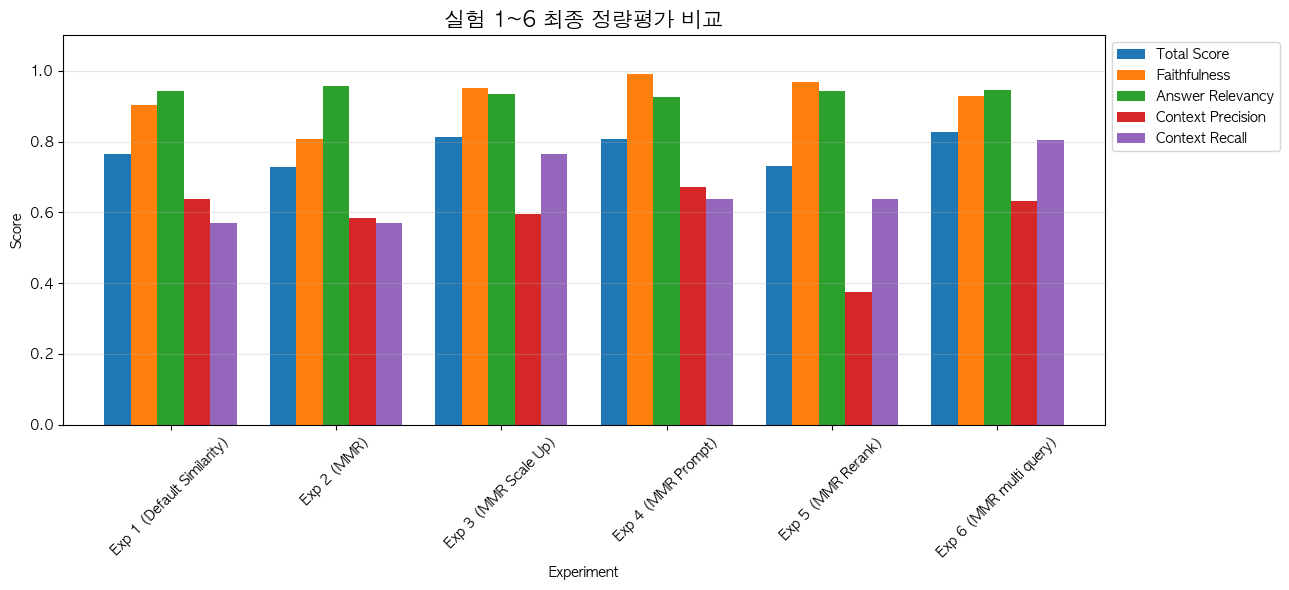

In [62]:
visualize_rag_comparison({
    "Exp 1 (Default Similarity)": globals().get('result_default'),
    "Exp 2 (MMR)": globals().get('result_mmr'),
    "Exp 3 (MMR Scale Up)": globals().get('result_improved_mmr'),
    "Exp 4 (MMR Prompt)": globals().get('result_prompt_tuned'),
    "Exp 5 (MMR Rerank)": globals().get('result_rerank'),
    "Exp 6 (MMR multi query)": globals().get('result_mq')
}, title="실험 1~6 최종 정량평가 비교")

In [63]:
from langchain_core.output_parsers import JsonOutputParser
from pydantic import BaseModel, Field
from langchain_core.prompts import PromptTemplate

# 1. 정성평가 결과 구조화를 위한 Pydantic 모델 정의
class JudgeResult(BaseModel):
    score: int = Field(description="1~5점 사이의 점수 (정수)")
    critique: str = Field(description="답변의 장단점에 대한 구체적이고 전문적인 비평")
    improvement_points: str = Field(description="더 나은 답변을 위해 보완할 점")

# 2. JSON 출력 파서 설정
parser = JsonOutputParser(pydantic_object=JudgeResult)

# 3. 정성평가 전용 판사 프롬프트 정의
# 문맥(Context)을 충분히 활용할 수 있도록 가이드를 강화했습니다.
judge_template = """
당신은 문학 전문 비평가이자 RAG 시스템 평가 전문가입니다.
제공된 문맥(Context)과 실제 정답(Reference)을 바탕으로 인공지능의 답변(Response)을 정성적으로 비평하세요.
반드시 아래의 JSON 형식으로만 답변해야 합니다.

{format_instructions}

[평가 지침]
1. 정확성: 정답(Reference)의 핵심 내용을 빠짐없이 포함하고 있는가?
2. 논리성: 제공된 문맥(Context)에서 유추할 수 있는 내용을 근거로 답변했는가? (근거 없는 지어냄 주의)
3. 가독성: 문장이 자연스럽고 문학적 맥락을 잘 전달하고 있는가?

[데이터]
- 질문: {question}
- 문맥: {context}
- 실제 정답: {reference}
- 인공지능 답변: {response}
"""

judge_prompt = PromptTemplate(
    template=judge_template,
    input_variables=["question", "context", "reference", "response"],
    partial_variables={"format_instructions": parser.get_format_instructions()},
)


judge_llm = ChatOpenAI(model="gpt-5", temperature=0) 

def run_qualitative_judge(result, target_idx=None, sample_count=1, silent=False):
    """
    RAGAS 평가 결과(result)를 바탕으로 정성평가를 수행합니다.
    버그 수정 사항: 
    - 입력을 유연하게 처리 (컬럼명 자동 매핑)
    - 문맥 전체 결합 (정보 누락 방지)
    - 에러 발생 시 평균 점수 계산 제외
    """
    # 1. 데이터프레임 변환 및 컬럼명 유연성 확보
    df = result.to_pandas()
    
    # Ragas 기본 컬럼명과 사용자 정의 컬럼명 모두 대응
    col_map = {
        'q': 'user_input' if 'user_input' in df.columns else 'question',
        'c': 'retrieved_contexts' if 'retrieved_contexts' in df.columns else 'contexts',
        'ref': 'reference' if 'reference' in df.columns else 'ground_truth',
        'res': 'response' if 'response' in df.columns else 'answer'
    }
    
    # 2. 평가 대상 샘플 선정
    if target_idx is not None:
        if target_idx >= len(df):
            print(f"Error: 인덱스 {target_idx}가 데이터 범위를 벗어났습니다. (최대 {len(df)-1})")
            return 0
        samples = df.iloc[[target_idx]]
    else:
        samples = df.head(sample_count)
    
    # 평가 체인 구성
    judge_chain = judge_prompt | judge_llm | parser
    total_score = 0
    valid_eval_count = 0 
    
    for i, row in samples.iterrows():
        try:
            raw_contexts = row.get(col_map['c'], [])
            if isinstance(raw_contexts, list):
                context_text = "\n\n".join([str(c) for c in raw_contexts])
            else:
                context_text = str(raw_contexts)
                
            # 판사 비평 실행
            res_json = judge_chain.invoke({
                "question": row.get(col_map['q'], ""),
                "context": context_text[:2500], # 문맥 손실 방지를 위해 대폭 확대
                "reference": row.get(col_map['ref'], ""),
                "response": row.get(col_map['res'], "")
            })
            
            score = res_json.get('score', 0)
            critique = res_json.get('critique', "비평 생성 실패")
            improvement = res_json.get('improvement_points', "개선점 없음")
            valid_eval_count += 1
            
        except Exception as e:
            print(f"Error processing sample {i+1}: {e}")
            score = 0
            critique = "평가 도중 에러가 발생했습니다."
            improvement = str(e)
            
        total_score += score
        
        # 상세 출력
        if not silent:
            print(f"\n[{i+1}번 샘플 상세 모니터링]")
            print(f"📖 정답(Ref): {row.get(col_map['ref'], '')[:100]}...")
            print(f"🤖 모델답변: {row.get(col_map['res'], '')}")
            print("-" * 30)
            print(f"⚖️ 점수: {score}점")
            print(f"💬 비평: {critique}")
            print(f"💡 개선점: {improvement}")
            print("=" * 80)

    # 3. 평균 점수 계산 (성공한 평가에 대해서만 산출하여 점수 왜곡 방지)
    avg_score = total_score / valid_eval_count if valid_eval_count > 0 else 0
    
    print(f"\n✅ 정성평가 완료 (대상: {len(samples)}건, 성공: {valid_eval_count}건)")
    print(f"📊 최종 평균 점수: {avg_score:.2f} / 5.0")
    
    return avg_score


In [64]:
test_score = run_qualitative_judge(result_default, target_idx=1, silent=False)
print(f"\n✅ 테스트 완료! 최종 점수: {test_score}점")


[2번 샘플 상세 모니터링]
📖 정답(Ref): Demian is described as having an expression that is elegant and at ease, with a glance showing deep,...
🤖 모델답변: Demian is a character who is surrounded by rumors and intrigue. He is known for his physical prowess, having humiliated the strongest boy in his class without resorting to a traditional fight. There are also rumors about his and his mother's religious affiliations, with some speculating they might be Jews or Mohammedans. Demian's mother is described as wealthy, youthful, and charming, with a regal presence. Demian and his mother do not attend church, and they seem to live in a way that sets them apart from the conventional world, representing a different kind of vision and potentiality.
------------------------------
⚖️ 점수: 2점
💬 비평: 정답의 핵심 묘사(우아하고 태연한 표정, 깊고 고요하면서도 거의 광신적 열정의 시선, 남성도 유아도 노년도 청년도 아닌 무시간적 얼굴, 다른 시대의 표식, 동물·정령·형상처럼 보이는 이질성)가 거의 전부 누락되었습니다. 응답은 문맥에서 확인 가능한 소문(종교적 소속 추측, 교회 불참, 체력, 부유한 어머니)과 어머니의 외양을 장황하게 서술하지만, 질문의 초점인 ‘데미안이 누구인가’에 대한 

In [65]:
experiment_data = [
    ("실험 1: Default (Similarity)", result_default),
    ("실험 2: MMR", result_mmr),
    ("실험 3: Improved MMR", result_improved_mmr),
    ("실험 4: Prompt Tuned", result_prompt_tuned),
    ("실험 5: Reranking", result_rerank),
    ("실험 6: Multi-Query", result_mq)
]

ranks = []
print("🔍 모든 실험의 정성적 완성도를 판사(LLM)가 검토 중입니다...")

for name, res in experiment_data:
    if res is not None:
        final_avg_score = run_qualitative_judge(res, target_idx=None, sample_count=6, silent=True)
        print(f"\n{name}: {final_avg_score}")
        ranks.append({"실험명": name, "정성평가 점수": final_avg_score})

# 데이터프레임으로 변환 후 점수순 정렬
rank_df = pd.DataFrame(ranks).sort_values(by="정성평가 점수", ascending=False).reset_index(drop=True)

print("\n" + "="*50)
print("🏅 정성평가(LLM-as-a-Judge) 최종 순위표")
print("="*50)
display(rank_df)



🔍 모든 실험의 정성적 완성도를 판사(LLM)가 검토 중입니다...

✅ 정성평가 완료 (대상: 6건, 성공: 6건)
📊 최종 평균 점수: 3.17 / 5.0

실험 1: Default (Similarity): 3.1666666666666665

✅ 정성평가 완료 (대상: 6건, 성공: 6건)
📊 최종 평균 점수: 2.67 / 5.0

실험 2: MMR: 2.6666666666666665

✅ 정성평가 완료 (대상: 6건, 성공: 6건)
📊 최종 평균 점수: 3.00 / 5.0

실험 3: Improved MMR: 3.0

✅ 정성평가 완료 (대상: 6건, 성공: 6건)
📊 최종 평균 점수: 3.33 / 5.0

실험 4: Prompt Tuned: 3.3333333333333335

✅ 정성평가 완료 (대상: 6건, 성공: 6건)
📊 최종 평균 점수: 2.83 / 5.0

실험 5: Reranking: 2.8333333333333335

✅ 정성평가 완료 (대상: 6건, 성공: 6건)
📊 최종 평균 점수: 2.83 / 5.0

실험 6: Multi-Query: 2.8333333333333335

🏅 정성평가(LLM-as-a-Judge) 최종 순위표


,실험명,정성평가 점수
0,실험 4: Prompt Tuned,3.333333
1,실험 1: Default (Similarity),3.166667
2,실험 3: Improved MMR,3.000000
3,실험 5: Reranking,2.833333
4,실험 6: Multi-Query,2.833333
5,실험 2: MMR,2.666667


### 📊 RAGAS(정량) vs LLM-as-a-Judge(정성) 결과 비교 분석

실험 결과 데이터에 따르면 정량 지표(**RAGAS**)에서는 **실험 6**이 가장 우수했으나, 정성 평가(**LLM 판사**)에서는 **실험 4**가 최고점을 기록했습니다. 이는 각 평가 도구가 측정하고자 하는 핵심 가치가 다르기 때문입니다.

#### **1. RAGAS 결과: 실험 6 (Multi-Query) 우세 원인**
RAGAS는 시스템이 답변을 생성하기 위해 "필요한 재료(Context)를 얼마나 기술적으로 완벽하게 찾아왔는가"**에 집중합니다.

*   **Context Recall(재현율)의 극대화**: 실험 6은 질문을 3가지 관점으로 확장하여 검색을 수행했습니다. 이를 통해 단일 검색어로는 놓치기 쉬운 정보들을 넓게 수집하여 **Context Recall 0.8056**이라는 가장 높은 수치를 기록했습니다.
*   **기술적 무결성**: RAGAS는 검색된 문맥과 정답 사이의 통계적 유사성을 계산하므로, 정보의 양이 풍부하고 검색 누락이 적은 실험 6을 기술적으로 가장 우수하다고 판단했습니다.

#### **2. LLM-as-a-Judge 결과: 실험 4 (Prompt Tuned) 우세 원인**
LLM 판사는 수치적 일치율보다 **"답변이 얼마나 인간이 읽기에 논리적이고 문학적 맥락에 부합하는가"**라는 정성적 완성도를 우선시합니다.

*   **답변의 질적 최적화 (Prompt Tuning)**: 실험 4는 충분한 검색 범위(k=6)를 확보한 상태에서 **답변 지침(Prompt)을 최적화**한 모델입니다. "아는 척"은 방지하되 본문 내 단서의 연결성을 강화하도록 설계되었습니다.
*   **정성적 만족도**: 판사 모델은 단순히 정보가 많은 것보다, 추출된 정보를 바탕으로 얼마나 가독성 있고 논리적으로 답변을 구성했는지를 높게 평가합니다. 실험 4는 최적화된 프롬프트를 통해 가장 전문적인 답변을 내놓았기에 **3.33점**으로 1위를 차지했습니다.

---

#### **💡 요약 비교표**

| 구분 | RAGAS (실험 6 우세) | LLM-as-a-Judge (실험 4 우세) |
| :--- | :--- | :--- |
| **평가 성격** | 기술적/수치적 채점 (정량) | 비평적/언어적 채점 (정성) |
| **핵심 지표** | 정보의 검색량 및 재현율(Recall) | 답변의 논리성 및 가독성 |
| **비유** | **"요리에 필요한 재료가 다 준비되었는가?"** | **"완성된 요리의 맛과 플레이팅이 좋은가?"** |
| **결론** | 리트리버(검색) 성능이 가장 뛰어남 | 제너레이터(생성) 품질이 가장 뛰어남 |


## 💡 회고 (Retrospective)
### 1. 이번 프로젝트를 하면서 느낀 점과 배운 점
* 지표의 다각화 (RAGAS vs Judge): 통계적 정량 지표(RAGAS)와 인간의 직관을 대변하는 정성 지표(LLM Judge) 사이의 간극을 이해하게 되었습니다. RAGAS는 "재료의 완결성"을, LLM 판사는 "요리의 완성도"를 본다는 차이를 실험으로 증명했습니다
* 검색 전략의 중요성: 기술적으로 재현율(Recall)을 높이기 위해 **멀티쿼리(Multi-Query)**와 MMR 설정을 고도화하는 과정을 통해, 단순히 데이터를 넣는 것보다 '어떻게 찾아오는가'가 RAG의 핵심임을 배웠습니다. 

### 2. 이번 프로젝트에서 잘했다고 생각하는 점
* 체계적인 파라미터 튜닝 (AB Test): 단순 추측이 아닌, Chunk Size, Overlap, K값 등을 단계별로 변경하며 RAGAS 수치 변화를 추적하여 최적의 조합을 찾아냈습니다.
* 프롬프트 엔지니어링을 통한 신뢰도 확보: 실험 4를 통해 Faithfulness 경이로운 수치를 기록하며, 모델의 환각(Hallucination)을 거의 완벽하게 제어하는 'Balanced Prompt'를 구축해 냈습니다.
* FlashRank와 멀티쿼리 방식을 도입해 보다 다양하게 테스트를 했습니다.

### 3. 이번 프로젝트에서 느낀 문제점 및 한계점
* 샘플 사이즈의 한계: 6개의 테스트 샘플만으로는 전체 도서 내용에 대한 통계적 유의성을 완벽히 확보하기에 부족했습니다. 더 방대한 테스트셋 구축이 필요합니다.
* 리랭커(FlashRank)의 문학적 한계: 사실 관계 중심의 리랭커 모델이 소설 특유의 비유와 심리 묘사를 질문과 매칭하는 데 한계가 있음을 확인했습니다


### 4. 다음 프로젝트/실무를 위해 개선해야 할 점 (Action Items)
* 고급 리랭커 도입: 문학적 문맥 이해도가 더 높은 Cross-Encoder 기반의 상위 모델(예: BGE-Reranker 등)을 도입하여, 멀티쿼리에서 발생하는 노이즈를 더 정교하게 필터링해 보겠습니다.
